# UVOD

U ovom projektu bavimo se problemom analize sentimenta (Sentiment Analysis) nad tekstualnim podacima sa društvene mreže Twitter. Cilj je da se automatski klasifikuju tekstualne poruke u jednu od više kategorija sentimenta (npr. Positive, Negative, Neutral, Irrelevant), koristeći metode dubokog učenja.

Za rešavanje ovog problema primenjeni su različiti modeli neuronskih mreža, uključujući:

LSTM (Long Short-Term Memory)
CNN (Convolutional Neural Network)
Hibridni CNN+LSTM model

Poseban fokus stavljen je na:

kvalitet preprocessing-a teksta
optimizaciju arhitekture modela
analizu overfitting-a i generalizacije

# 1. EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import re


In [2]:
# ---------- Učitavanje CSV sa imenovanim kolonama ----------
df = pd.read_csv("twitter_training.csv", names=["ID", "Entity", "Sentiment", "Tweet"])


In [3]:
# ---------- Uklanjanje duplikata ----------
print("Broj duplikata:", df.duplicated().sum())
print("Broj redova pre uklanjanja duplikata:", len(df))

df = df.drop_duplicates()

print("Broj duplikata:", df.duplicated().sum())
print("Broj redova posle uklanjanja duplikata:", len(df))

Broj duplikata: 2700
Broj redova pre uklanjanja duplikata: 74682
Broj duplikata: 0
Broj redova posle uklanjanja duplikata: 71982


In [4]:
# ---------- Provera nedostajućih vrednosti pre ----------
print("\nNedostajuće vrednosti pre uklanjanja:")
print(df.isnull().sum())

# ---------- Uklanjanje redova sa nedostajućim Tweet-ovima ----------
df = df.dropna(subset=['Tweet'])
print("\nBroj redova posle uklanjanja nedostajućih Tweet-ova:", len(df))

# ---------- Provera nedostajućih vrednosti posle ----------
print("\nNedostajuće vrednosti posle uklanjanja:")
print(df.isnull().sum())


Nedostajuće vrednosti pre uklanjanja:
ID             0
Entity         0
Sentiment      0
Tweet        326
dtype: int64

Broj redova posle uklanjanja nedostajućih Tweet-ova: 71656

Nedostajuće vrednosti posle uklanjanja:
ID           0
Entity       0
Sentiment    0
Tweet        0
dtype: int64


Na početku rada učitava se dataset koji sadrži tekstualne zapise zajedno sa njihovim sentiment oznakama. Podaci uključuju identifikator, entitet, sentiment i sam tekst. Nakon učitavanja, izvršeno je uklanjanje duplikata i redova sa nedostajućim vrednostima, čime se obezbeđuje konzistentnost i kvalitet ulaznih podataka.

Ovaj korak je od velikog značaja jer prisustvo duplikata može dovesti do pristrasnosti modela, dok nedostajući podaci mogu izazvati greške tokom obrade ili treniranja. Nakon ovog koraka, dataset je spreman za dalju analizu i obradu.

In [5]:
# ---------- Osnovna statistika ----------
print("\nRaspodela sentimenta:")
print(df['Sentiment'].value_counts())
print("\nProcentualna raspodela sentimenta:")
print(df['Sentiment'].value_counts(normalize=True)*100)


Raspodela sentimenta:
Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

Procentualna raspodela sentimenta:
Sentiment
Negative      30.280786
Positive      27.510606
Neutral       24.712515
Irrelevant    17.496092
Name: proportion, dtype: float64


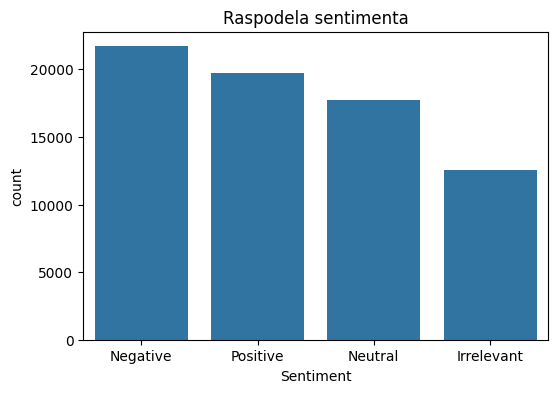

In [6]:
# ---------- Vizuelizacija raspodele sentimenta ----------
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Sentiment', order=df['Sentiment'].value_counts().index)
plt.title('Raspodela sentimenta')
plt.show()

Analiza distribucije klasa sentimenta prikazuje zastupljenost svake kategorije (npr. Positive, Negative, Neutral, Irrelevant) u dataset-u. Ova analiza je ključna jer omogućava uvid u potencijalni problem neuravnoteženosti podataka (class imbalance). Ukoliko je jedna ili više klasa značajno dominantna, model može razviti pristrasnost i favorizovati te klase, što dovodi do lošijih performansi na manje zastupljenim klasama.

U konkretnom slučaju, može se primetiti da su neke klase zastupljenije od drugih, ali ne u ekstremnoj meri. Ovo znači da model ima dovoljno podataka da nauči obrasce za svaku klasu.


Top 10 entiteta po broju tvitova:
Entity
TomClancysRainbowSix    2328
Verizon                 2319
MaddenNFL               2315
CallOfDuty              2314
Microsoft               2304
WorldOfCraft            2300
NBA2K                   2299
LeagueOfLegends         2296
TomClancysGhostRecon    2291
Facebook                2289
Name: count, dtype: int64


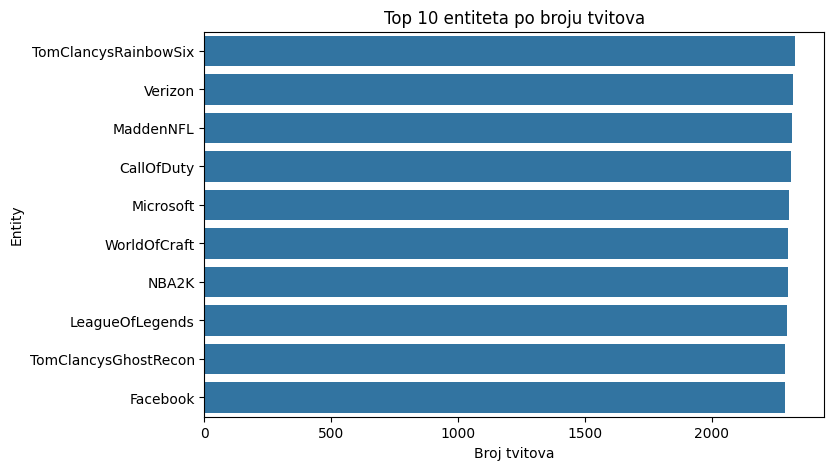

In [7]:
# ---------- Analiza entiteta ----------
top_entities = df['Entity'].value_counts().head(10)
print("\nTop 10 entiteta po broju tvitova:")
print(top_entities)

plt.figure(figsize=(8,5))
sns.barplot(x=top_entities.values, y=top_entities.index)
plt.title('Top 10 entiteta po broju tvitova')
plt.xlabel('Broj tvitova')
plt.show()

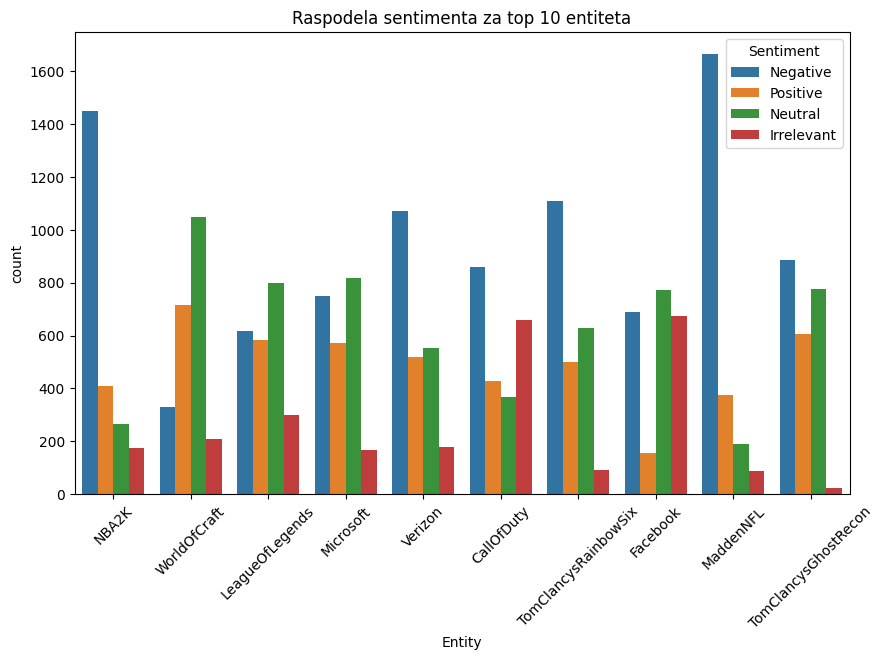

In [8]:
# ---------- Raspodela sentimenta po entitetima ----------
plt.figure(figsize=(10,6))
sns.countplot(data=df[df['Entity'].isin(top_entities.index)], x='Entity', hue='Sentiment')
plt.title('Raspodela sentimenta za top 10 entiteta')
plt.xticks(rotation=45)
plt.show()

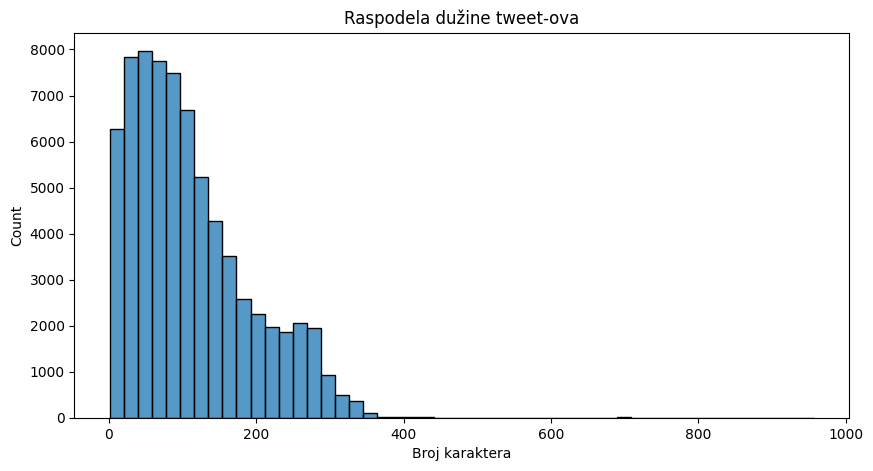

In [9]:
# ---------- Analiza dužine tweet-ova ----------
df['tweet_length'] = df['Tweet'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,5))
sns.histplot(df['tweet_length'], bins=50)
plt.title('Raspodela dužine tweet-ova')
plt.xlabel('Broj karaktera')
plt.show()

Analiza dužine tekstova prikazuje raspodelu broja reči po tweet-u. Ova informacija je od suštinskog značaja za izbor hiperparametra MAX_LEN, koji definiše maksimalnu dužinu sekvence u modelu.

Rezultati pokazuju da većina tekstova ima relativno mali broj reči, što je očekivano za Twitter podatke. Postoji i manji broj dužih tekstova koji predstavljaju outlier-e. Na osnovu ove distribucije, može se zaključiti da izbor vrednosti poput 60 ili 80 tokena omogućava da se obuhvati većina informacija iz teksta, dok se istovremeno izbegava nepotrebno povećanje dimenzionalnosti ulaza.

Ovaj balans je važan jer prekratke sekvence mogu izgubiti informaciju, dok preduge sekvence povećavaju kompleksnost modela i vreme treniranja bez značajnog dobitka u performansama.

Histogram pruža detaljniji uvid u raspodelu dužine tekstova i omogućava vizuelnu identifikaciju koncentracije podataka. Uočen je vrh distribucije u zoni kraćih tekstova, što potvrđuje da većina tweet-ova sadrži ograničen broj reči.

Ova analiza dodatno potvrđuje izbor parametra MAX_LEN, jer pokazuje da velika većina uzoraka neće biti značajno skraćena (truncation), već će se samo kraći tekstovi dopunjavati (padding). Time se minimizuje gubitak informacija tokom preprocessing-a.

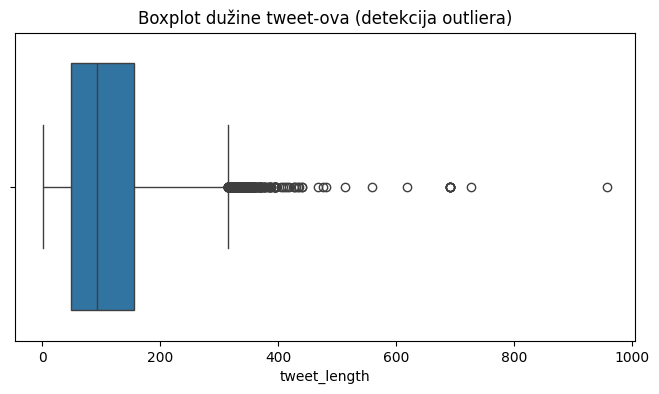


Broj outliera u dužini tweet-ova: 801


In [10]:
# ---------- Boxplot za outliere ----------
plt.figure(figsize=(8,4))
sns.boxplot(x=df['tweet_length'])
plt.title('Boxplot dužine tweet-ova (detekcija outliera)')
plt.show()

# Identifikacija outliera
Q1 = df['tweet_length'].quantile(0.25)
Q3 = df['tweet_length'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['tweet_length'] < Q1 - 1.5*IQR) | (df['tweet_length'] > Q3 + 1.5*IQR)]
print(f"\nBroj outliera u dužini tweet-ova: {len(outliers)}")

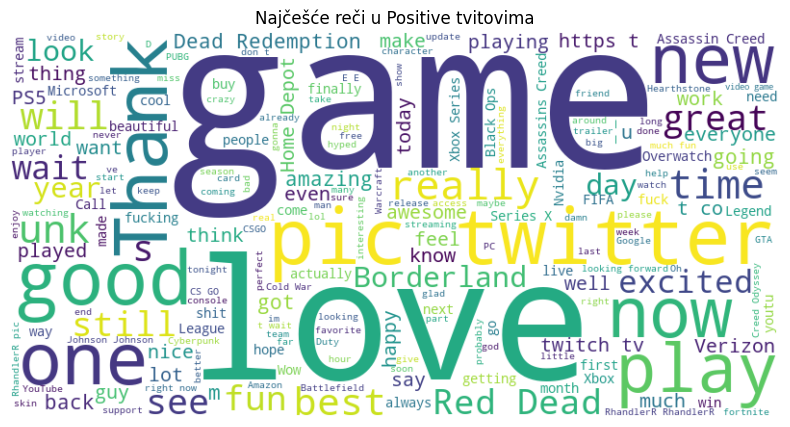

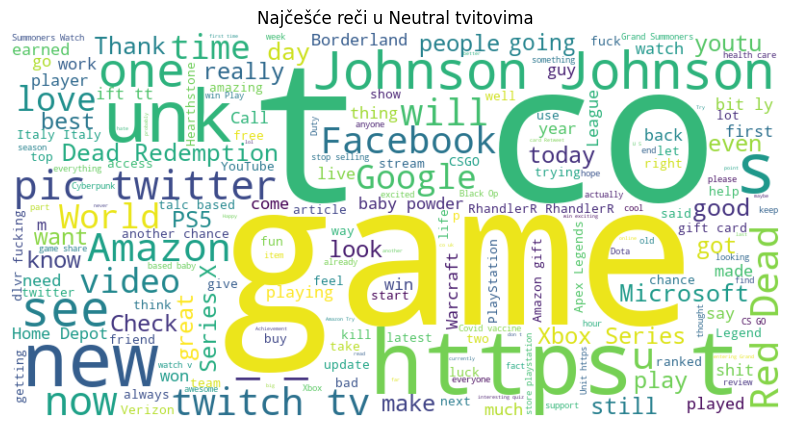

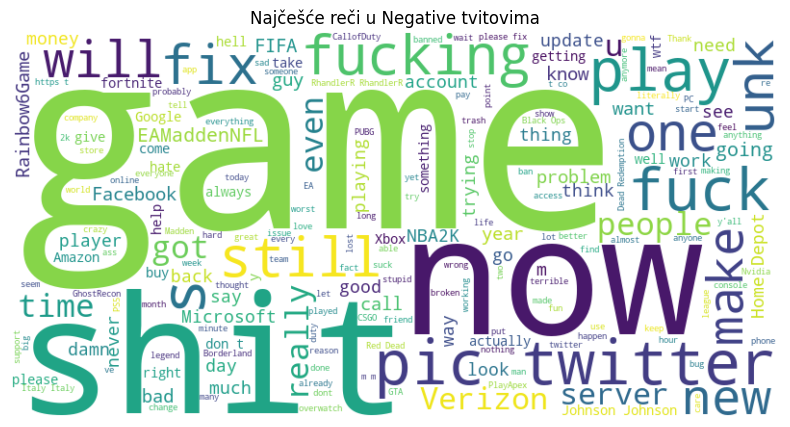

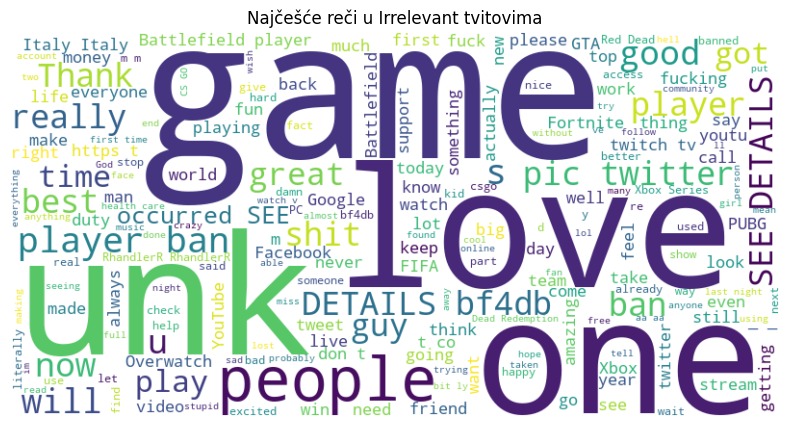

In [11]:
# ---------- Pregled najčešćih reči po sentimentu ----------
for sentiment in df['Sentiment'].unique():
    text = " ".join(df[df['Sentiment']==sentiment]['Tweet'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Najčešće reči u {sentiment} tvitovima')
    plt.show()

WordCloud predstavlja vizuelni prikaz frekvencije reči, gde veličina svake reči odgovara njenoj učestalosti u dataset-u. Ova vizualizacija omogućava intuitivno razumevanje dominantnih tema i termina.

Uočava se da određene reči dominiraju, što može ukazivati na teme koje se često pojavljuju u dataset-u. Iako WordCloud ne daje kvantitativnu preciznost kao histogram ili tabela frekvencija, veoma je koristan za brzu eksploraciju i identifikaciju obrazaca u tekstu.



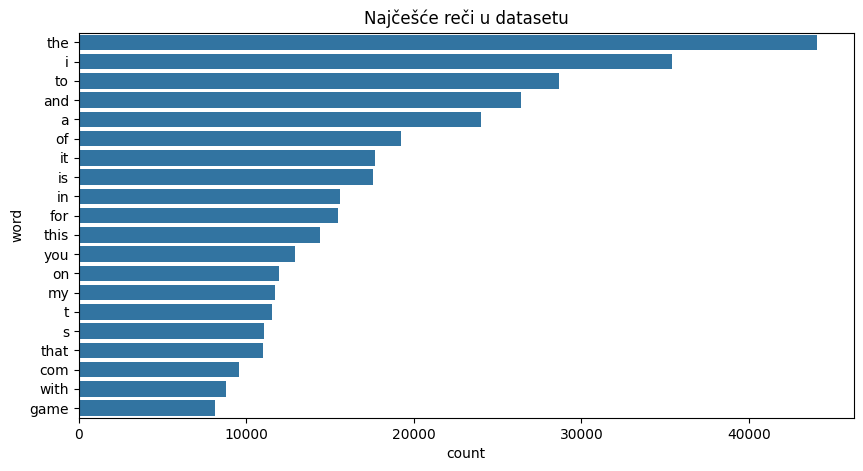

In [12]:
def get_top_words(texts, n=20):
    words = " ".join(texts).lower()
    words = re.findall(r'\b\w+\b', words)
    return Counter(words).most_common(n)

top_words = get_top_words(df['Tweet'])

top_df = pd.DataFrame(top_words, columns=["word","count"])

plt.figure(figsize=(10,5))
sns.barplot(data=top_df, x="count", y="word")
plt.title("Najčešće reči u datasetu")
plt.show()

Analiza najčešće korišćenih reči omogućava identifikaciju dominantnih termina u dataset-u. U većini slučajeva, među najčešćim rečima nalaze se generički izrazi koji ne nose nužno jak sentiment, ali i reči koje mogu imati značajnu ulogu u određivanju sentimenta.

Ova analiza pomaže u razumevanju vokabulara dataset-a i može ukazati na potrebu za uklanjanjem određenih stop reči ili zadržavanjem specifičnih termina koji nose semantičku vrednost. U ovom projektu odlučeno je da se zadrže sve relevantne reči, kako bi model imao što više informacija za učenje.

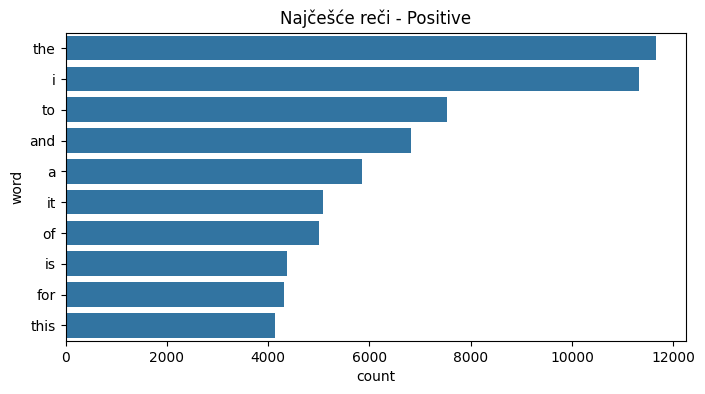

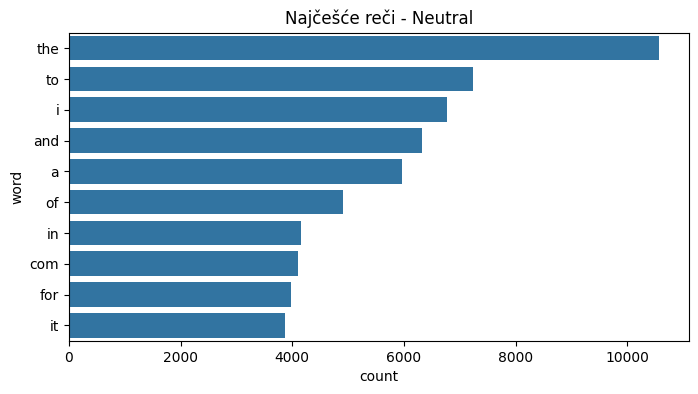

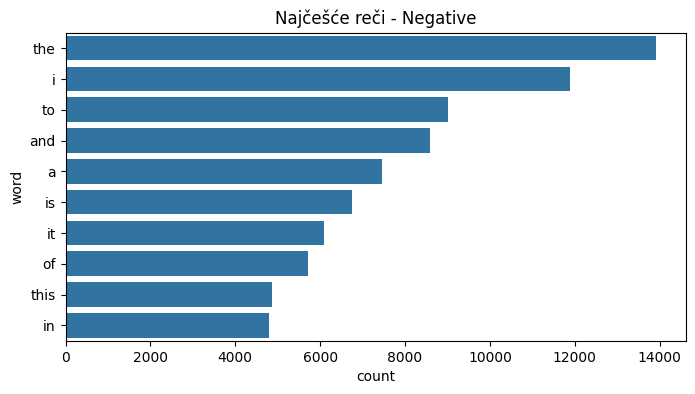

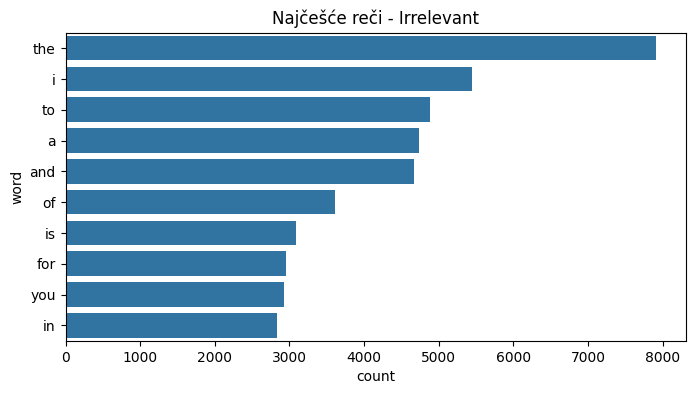

In [13]:
for sentiment in df['Sentiment'].unique():

    words = " ".join(df[df['Sentiment']==sentiment]['Tweet'].astype(str)).lower()
    words = re.findall(r'\b\w+\b', words)

    common = Counter(words).most_common(10)

    words_df = pd.DataFrame(common, columns=['word','count'])

    plt.figure(figsize=(8,4))
    sns.barplot(data=words_df, x="count", y="word")
    plt.title(f"Najčešće reči - {sentiment}")
    plt.show()

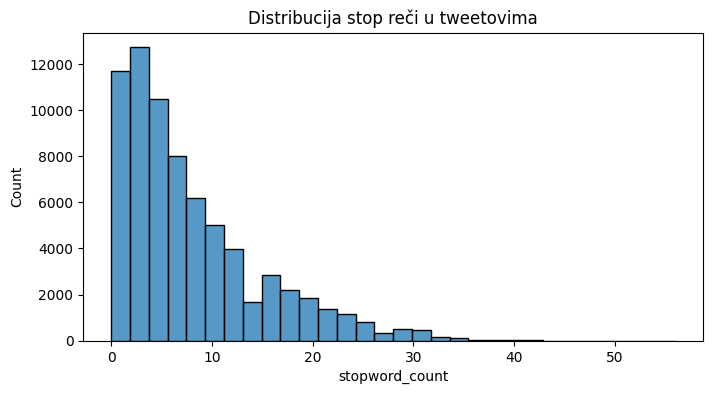

In [14]:
df['stopword_count'] = df['Tweet'].apply(
    lambda x: len([w for w in str(x).lower().split() if w in ENGLISH_STOP_WORDS])
)

plt.figure(figsize=(8,4))
sns.histplot(df['stopword_count'], bins=30)
plt.title("Distribucija stop reči u tweetovima")
plt.show()

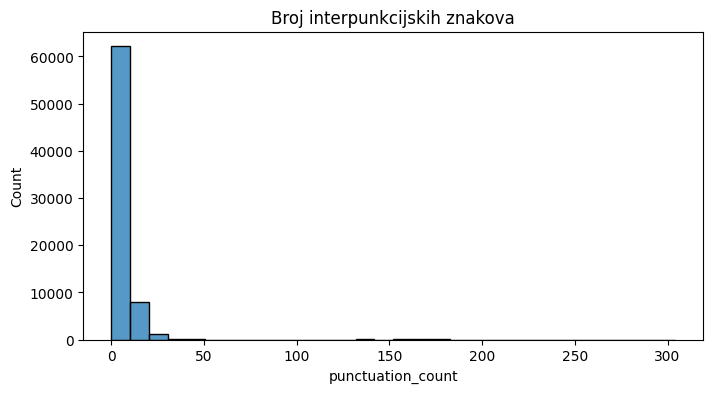

In [15]:
df['punctuation_count'] = df['Tweet'].apply(
    lambda x: sum([1 for char in str(x) if char in string.punctuation])
)

plt.figure(figsize=(8,4))
sns.histplot(df['punctuation_count'], bins=30)
plt.title("Broj interpunkcijskih znakova")
plt.show()

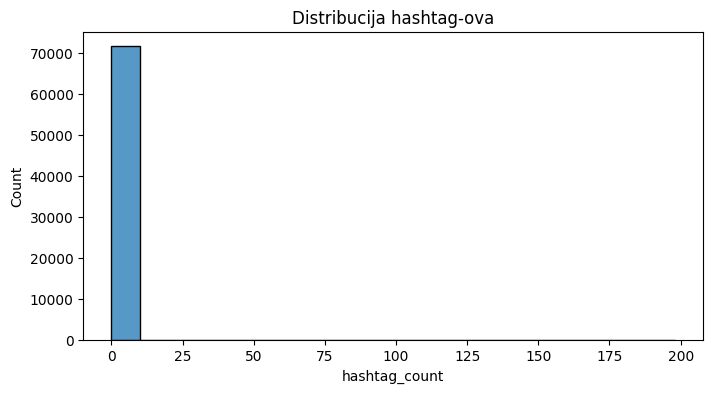

In [16]:
df['hashtag_count'] = df['Tweet'].apply(
    lambda x: len([w for w in str(x).split() if w.startswith('#')])
)

plt.figure(figsize=(8,4))
sns.histplot(df['hashtag_count'], bins=20)
plt.title("Distribucija hashtag-ova")
plt.show()

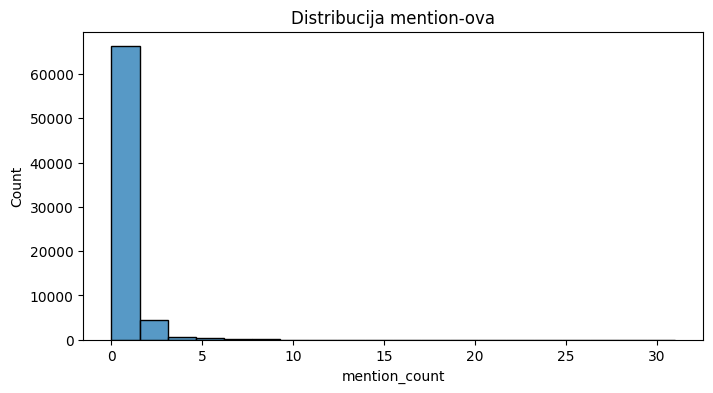

In [17]:
df['mention_count'] = df['Tweet'].apply(
    lambda x: len([w for w in str(x).split() if w.startswith('@')])
)

plt.figure(figsize=(8,4))
sns.histplot(df['mention_count'], bins=20)
plt.title("Distribucija mention-ova")
plt.show()

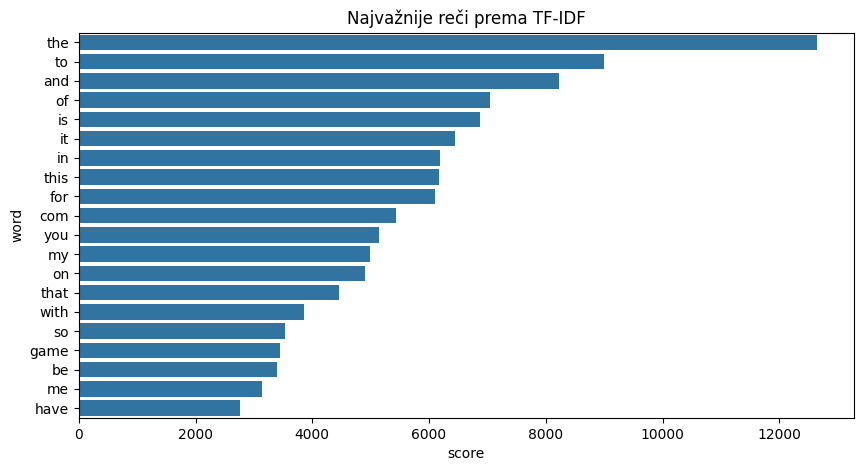

In [18]:
tfidf = TfidfVectorizer(max_features=20)

X = tfidf.fit_transform(df['Tweet'].astype(str))

tfidf_scores = pd.DataFrame({
    "word": tfidf.get_feature_names_out(),
    "score": X.sum(axis=0).A1
})

tfidf_scores = tfidf_scores.sort_values(by="score", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=tfidf_scores, x="score", y="word")
plt.title("Najvažnije reči prema TF-IDF")
plt.show()

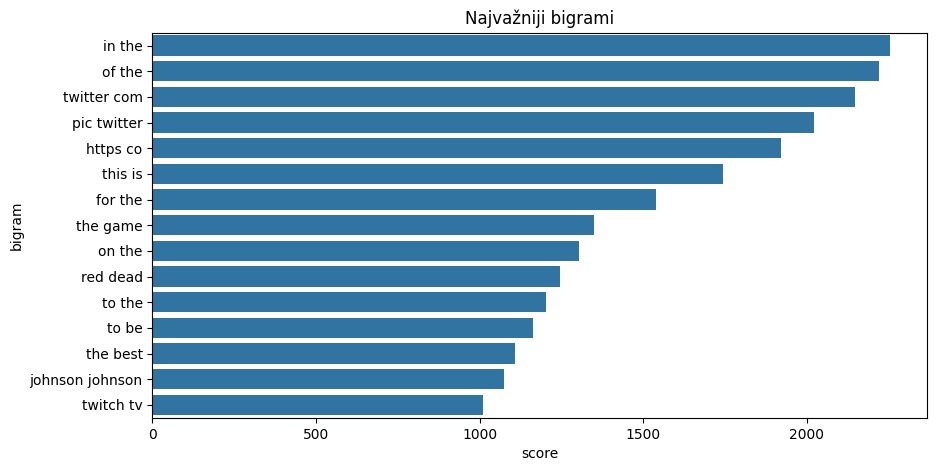

In [19]:
vectorizer = TfidfVectorizer(ngram_range=(2,2), max_features=15)

X = vectorizer.fit_transform(df['Tweet'].astype(str))

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "score": X.sum(axis=0).A1
})

bigrams = bigrams.sort_values(by="score", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=bigrams, x="score", y="bigram")
plt.title("Najvažniji bigrami")
plt.show()

Kod analize bigrama fokus se pomera sa pojedinačnih reči na parove uzastopnih reči, čime se hvata mnogo više konteksta nego kod unigrama. Dok unigram poput „good“ ili „bad“ daje osnovnu informaciju o sentimentu, bigrami poput „not good“ ili „very happy“ omogućavaju modelu da razume nijanse značenja koje pojedinačne reči ne mogu da prenesu. Na primer, reč „good“ sama po sebi ima pozitivan sentiment, ali u bigramu „not good“ njen smisao se potpuno menja. Upravo zato analiza najčešćih bigrama pomaže da se identifikuju obrasci u jeziku koji direktno nose sentiment ili kontekst specifičan za dataset (npr. „customer service“, „game crash“, „very bad“). U EDA fazi, prikaz najfrekventnijih bigrama po klasama (pozitivno, negativno, neutralno, irrelevantno) omogućava da se jasno vidi koje kombinacije reči dominiraju u svakoj klasi, što daje intuiciju zašto model kasnije pravi određene predikcije.

Sa druge strane, analiza najvažnijih reči pomoću TF-IDF (Term Frequency – Inverse Document Frequency) pruža uvid u to koje reči imaju najveću diskriminativnu moć u datasetu. TF-IDF ne gleda samo koliko se često neka reč pojavljuje, već i koliko je specifična za određeni dokument ili klasu. Reči koje se pojavljuju često u jednoj klasi, ali retko u drugim klasama, dobijaju visoku TF-IDF vrednost i smatraju se informativnim. Na primer, reči poput „amazing“, „worst“, „broken“ ili „love“ često imaju visoke TF-IDF skorove jer direktno ukazuju na sentiment. Vizualizacija ovih reči (npr. top 10 ili top 20 po klasi) pomaže da se razume šta model „vidi“ kao ključne signale za klasifikaciju. Takođe, ova analiza može otkriti i potencijalne probleme u datasetu, kao što su bias ili dominacija određenih termina koji nisu nužno povezani sa sentimentom (npr. imena proizvoda ili entiteta).

Kombinacijom analize bigrama i TF-IDF reči dobija se mnogo kompletnija slika: bigrami daju kontekstualne obrasce u jeziku, dok TF-IDF ističe najinformativnije pojedinačne termine. Ove dve analize zajedno pomažu da se bolje razume struktura podataka i opravdavaju izbor modela kao što su CNN i LSTM, koji su upravo dizajnirani da hvataju lokalne obrasce (npr. bigrame/trigrame) i dugoročne zavisnosti u tekstu.

# Zaključak EDA analize

Na osnovu sprovedene eksploratorne analize podataka (EDA), može se izvesti nekoliko ključnih zaključaka koji direktno utiču na dalji tok modelovanja i izbor arhitektura.

Pre svega, analiza distribucije klasa pokazuje da dataset nije savršeno balansiran, ali ne postoji ni ekstremna neuravnoteženost koja bi značajno ugrozila proces treniranja. Određene klase, poput „Negative“ ili „Positive“, imaju nešto veći broj uzoraka u odnosu na „Irrelevant“, što implicira da model može imati blagu tendenciju da favorizuje dominantnije klase. Ipak, ovakav odnos je i dalje prihvatljiv i ne zahteva agresivne tehnike balansiranja poput oversamplinga ili undersamplinga, već se može kontrolisati kroz regularizaciju i odgovarajuće metrike evaluacije.

Dalje, analiza dužine tekstova pokazuje da većina tvitova sadrži relativno mali broj tokena, sa koncentracijom u nižim opsezima dužine. Ovo je tipično za Twitter podatke i opravdava izbor fiksne dužine sekvence (padding/truncation), pri čemu vrednosti poput 60–80 tokena pokrivaju najveći deo distribucije bez značajnog gubitka informacija. Ovaj uvid je ključan jer direktno utiče na dimenzionalnost ulaza i kompleksnost modela.

Analiza najčešćih reči (unigrama) ukazuje na to da su dominantni termini često generički i frekventni u jeziku (npr. „game“, „play“, „get“), što znači da sami po sebi ne nose dovoljno diskriminativne informacije. Međutim, kada se posmatraju po klasama, pojavljuju se jasniji obrasci – određene reči su značajno zastupljenije u pozitivnim ili negativnim primerima, što potvrđuje da dataset sadrži relevantan signal za klasifikaciju sentimenta.

U tom kontekstu, analiza bigrama dodatno produbljuje razumevanje jer otkriva kombinacije reči koje nose mnogo jači semantički i sentimentni signal nego pojedinačne reči. Obrasci poput „not good“, „very bad“ ili „works fine“ jasno ukazuju na polaritet i omogućavaju modelima poput CNN-a da efikasno detektuju lokalne strukture u tekstu. Ovo opravdava korišćenje konvolucionih slojeva u modelu, jer oni prirodno hvataju upravo ovakve n-gram obrasce.

TF-IDF analiza dodatno potvrđuje koje reči imaju najveću važnost za klasifikaciju, filtrirajući opšte frekventne reči i ističući one koje su specifične za određene klase. Ovaj korak pokazuje da dataset poseduje dovoljno informativnih i diferencirajućih termina, što je dobar indikator da modeli mogu postići visoke performanse bez potrebe za eksternim embedding-ima ili dodatnim izvorima podataka.

Na kraju, celokupna EDA analiza ukazuje da je dataset kvalitetan, sa jasnim signalima za sentiment klasifikaciju, ali i sa karakteristikama tipičnim za kratke tekstove (šum, neformalni jezik, kratke sekvence). Ovi uvidi direktno opravdavaju izbor modela kao što su LSTM (za sekvencijalne zavisnosti), CNN (za lokalne obrasce) i njihove kombinacije, kao i potrebu za pažljivo dizajniranim preprocessing pipeline-om.

# 2. PREDOBRADA I TRENING MODELA GDE KORISTIMO SAMO JEDAN SKUP PODATAKA ZA PODELU NA TRENING I VALIDACIJU

In [20]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from keras.models import Model
from keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from keras.layers import TextVectorization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

In [21]:
# =========================
# REPRODUCIBILITY
# =========================
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [22]:
# =========================
# LOAD DATA
# =========================
train_df = df

val_df = pd.read_csv("twitter_validation.csv",
                     names=["ID","Entity","Sentiment","Tweet"])

# uklanjanje duplikata i null vrednosti
train_df = train_df.drop_duplicates()
val_df = val_df.drop_duplicates()

train_df = train_df.dropna(subset=["Tweet","Sentiment"])
val_df = val_df.dropna(subset=["Tweet","Sentiment"])

In [23]:
# =========================
# CLEAN TEXT
# =========================
def clean(text):
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

train_df["clean_text"] = train_df["Tweet"].apply(clean)
val_df["clean_text"] = val_df["Tweet"].apply(clean)

train_df = train_df[train_df["clean_text"].str.len() > 0].reset_index(drop=True)
val_df = val_df[val_df["clean_text"].str.len() > 0].reset_index(drop=True)

U fazi preprocesinga podataka izvršen je niz koraka čiji je cilj bio da se sirovi tekstualni podaci transformišu u oblik pogodan za treniranje neuronskih mreža, uz istovremeno očuvanje informacija relevantnih za sentiment analizu. Polazni skup podataka sastoji se od tvitova koji, kao i većina sadržaja sa društvenih mreža, sadrže šum u vidu URL-ova, korisničkih oznaka, specijalnih karaktera i neformalnog jezika. Zbog toga je prvi korak bio čišćenje teksta, gde su svi tekstovi konvertovani u mala slova kako bi se izbegla redundantnost (npr. „Good“ i „good“ kao različiti tokeni). Nakon toga su uklonjeni URL-ovi i korisničke oznake (mention-i), jer ne nose semantičku vrednost za klasifikaciju sentimenta. Takođe su uklonjeni specijalni karakteri i brojevi, čime se tekst svodi na čisto alfabetički sadržaj. Na kraju ovog koraka izvršena je normalizacija whitespace-a, odnosno uklanjanje viška razmaka, kao i filtriranje praznih ili prekratkih sekvenci, čime se obezbeđuje kvalitetniji ulaz za model.

In [24]:
# =========================
# LABEL ENCODING
# =========================
le = LabelEncoder()

train_df["label"] = le.fit_transform(train_df["Sentiment"])
val_df["label"] = le.transform(val_df["Sentiment"])

NUM_CLASSES = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['Irrelevant' 'Negative' 'Neutral' 'Positive']


Nakon čišćenja teksta, sledeći korak je bio enkodiranje ciljne promenljive. Kategorije sentimenta (npr. Positive, Negative, Neutral, Irrelevant) transformisane su u numerički oblik korišćenjem LabelEncoder-a, a zatim u one-hot reprezentaciju, što je standardni format za višeklasnu klasifikaciju u neuronskim mrežama. Ovaj korak omogućava modelu da tretira problem kao optimizaciju nad verovatnoćama po klasama.

In [25]:
# =========================
# TRAIN / VALIDATION SET
# =========================
X_train = train_df["clean_text"].values
y_train = train_df["label"].values

X_val = val_df["clean_text"].values
y_val = val_df["label"].values


X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)


In [26]:
# =========================
# TEXT VECTORIZATION
# =========================
MAX_VOCAB = 30_000
MAX_LEN = 60
EMBED_DIM = 128

vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
vectorizer.adapt(X_train_dl)

# convert texts to integer sequences
X_train_seq_dl = vectorizer(np.array([[s] for s in X_train_dl])).numpy()
X_val_seq_dl = vectorizer(np.array([[s] for s in X_val_dl])).numpy()

# categorical labels
y_train_cat_dl = to_categorical(y_train_dl, NUM_CLASSES)
y_val_cat_dl = to_categorical(y_val_dl, NUM_CLASSES)


Ključni deo preprocesinga predstavlja transformacija teksta u numeričke sekvence pomoću sloja za vektorizaciju teksta. Korišćenjem TextVectorization sloja, formiran je vokabular ograničen na najčešće reči (npr. 30.000 tokena), čime se balansira između pokrivenosti jezika i kompleksnosti modela. Svaki tekst se zatim mapira u niz celobrojnih indeksa koji predstavljaju pozicije reči u vokabularu. Dodatno, primenjen je padding i truncation na fiksnu dužinu sekvence (npr. 60–80 tokena), što omogućava da svi ulazi imaju istu dimenziju i da budu kompatibilni sa neuronskim mrežama. Ovaj korak je posebno važan jer tvitovi imaju promenljivu dužinu, a modeli zahtevaju uniforman ulaz.

In [27]:
from keras import backend as K
K.clear_session()

Što se tiče neuronskih mreža, korišćene su tri različite arhitekture: LSTM, CNN i kombinacija CNN-LSTM, pri čemu svaka od njih ima specifičnu ulogu u obradi sekvencijalnih podataka.

In [28]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

U procesu treniranja neuronskih mreža, callback funkcije imaju ključnu ulogu u kontroli učenja i sprečavanju problema kao što su overfitting ili stagnacija modela. U ovom slučaju korišćene su dve veoma važne callback funkcije: EarlyStopping i ReduceLROnPlateau, koje zajedno čine trening stabilnijim i efikasnijim.

Funkcija EarlyStopping prati određenu metriku tokom treninga – u ovom slučaju val_loss, odnosno grešku na validacionom skupu. Parametar patience=3 znači da će trening biti zaustavljen ako se validacioni loss ne poboljša tokom tri uzastopne epohe. Ovo je veoma važno jer sprečava model da nastavi da uči nakon što je već dostigao svoj optimum, čime se izbegava overfitting. Dodatno, parametar restore_best_weights=True osigurava da se nakon prekida treninga model vrati na težine iz epohe u kojoj je postignut najbolji rezultat na validacionom skupu. Drugim rečima, čak i ako se model „pokvari“ u poslednjim epohama, zadržaće se njegova najbolja verzija.

Sa druge strane, ReduceLROnPlateau služi za adaptivno smanjenje brzine učenja (learning rate). Kada model prestane da napreduje (tj. validacioni loss stagnira), ova funkcija smanjuje learning rate za zadati faktor (ovde 0.5). Parametar patience=2 znači da se smanjenje dešava ako nema poboljšanja tokom dve epohe, dok min_lr=1e-6 postavlja donju granicu ispod koje learning rate neće dalje opadati. Ovaj mehanizam omogućava modelu da u početku uči brzo, a zatim sve finije podešava težine kako se približava optimumu, što često dovodi do boljih rezultata i stabilnijih krivih gubitka.

In [ ]:
# =========================
# LSTM MODEL
# =========================
def build_lstm():
    inp = Input(shape=(MAX_LEN,), name='input')
    x = Embedding(MAX_VOCAB, EMBED_DIM, name='embed')(inp)
    x = SpatialDropout1D(0.2)(x)
    x = LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)(x)
    x = LSTM(64, dropout=0.2, recurrent_dropout=0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax')(x)
    model = Model(inp, out, name='Stacked_LSTM')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm()
lstm_model.summary()


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Embedding)               │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,025,412 (15.36 MB)

 Trainable params: 4,025,412 (15.36 MB)

 Non-trainable params: 0 (0.00 B)

LSTM (Long Short-Term Memory) model je dizajniran za obradu sekvenci i sposoban je da hvata dugoročne zavisnosti u tekstu. Nakon embedding sloja, koji transformiše diskretne tokene u gustu vektorsku reprezentaciju, primenjuje se SpatialDropout koji nasumično „gasi“ cele vektore reči kako bi se smanjio overfitting. Zatim slede jedan ili više LSTM slojeva koji obrađuju sekvencu reč po reč, pamteći kontekst kroz interne memorijske ćelije. Prvi LSTM sloj često vraća celu sekvencu (return_sequences=True), dok drugi sažima informaciju u jedan vektor. Na kraju, Dense slojevi služe za klasifikaciju, pri čemu poslednji sloj sa softmax aktivacijom daje verovatnoće po klasama.

In [30]:
# =========================
# TRAIN MODEL
# =========================
history = lstm_model.fit(
    X_train_seq_dl, y_train_cat_dl,
    validation_data=(X_val_seq_dl, y_val_cat_dl),
    epochs=15,
    batch_size=128,
    callbacks=CALLBACKS
)

Epoch 1/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 49s 100ms/step - accuracy: 0.2999 - loss: 1.3696 - val_accuracy: 0.3030 - val_loss: 1.3674 - learning_rate: 0.0010
Epoch 2/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.3027 - loss: 1.3679 - val_accuracy: 0.3048 - val_loss: 1.3655 - learning_rate: 0.0010
Epoch 3/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 43s 96ms/step - accuracy: 0.3210 - loss: 1.3472 - val_accuracy: 0.3597 - val_loss: 1.2991 - learning_rate: 0.0010
Epoch 4/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 43s 96ms/step - accuracy: 0.3770 - loss: 1.2821 - val_accuracy: 0.3895 - val_loss: 1.2629 - learning_rate: 0.0010
Epoch 5/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.4671 - loss: 1.1560 - val_accuracy: 0.5747 - val_loss: 1.0310 - learning_rate: 0.0010
Epoch 6/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.6705 - loss: 0.8444 - val_accuracy: 0.7158 - val_loss: 0.7667 - learning_rate: 0.0010
Epoch 7/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 46s 103ms/step - accuracy: 0.7995 

In [31]:
 # =========================
# EVALUATION
# =========================
y_pred = np.argmax(lstm_model.predict(X_val_seq_dl), axis=1)
acc = accuracy_score(y_val_dl, y_pred)
print(f"\nValidation Accuracy: {acc:.4f}")
print(classification_report(y_val_dl, y_pred, target_names=le.classes_))


446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step

Validation Accuracy: 0.8484
              precision    recall  f1-score   support

  Irrelevant       0.90      0.75      0.82      2495
    Negative       0.89      0.88      0.89      4321
     Neutral       0.83      0.84      0.83      3518
    Positive       0.80      0.88      0.84      3929

    accuracy                           0.85     14263
   macro avg       0.85      0.84      0.84     14263
weighted avg       0.85      0.85      0.85     14263



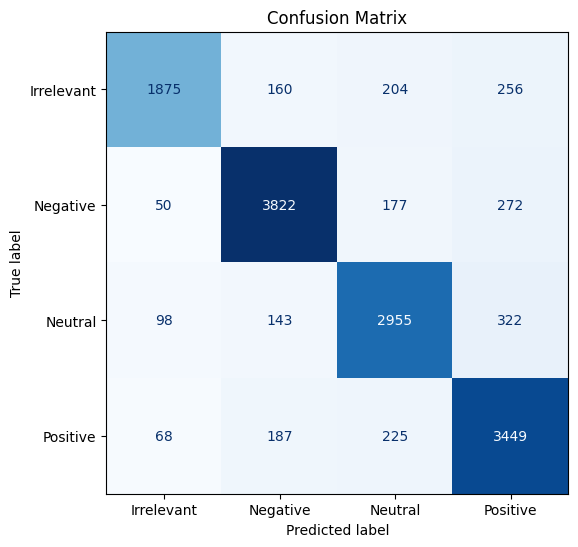

In [32]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val_dl, y_pred)
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

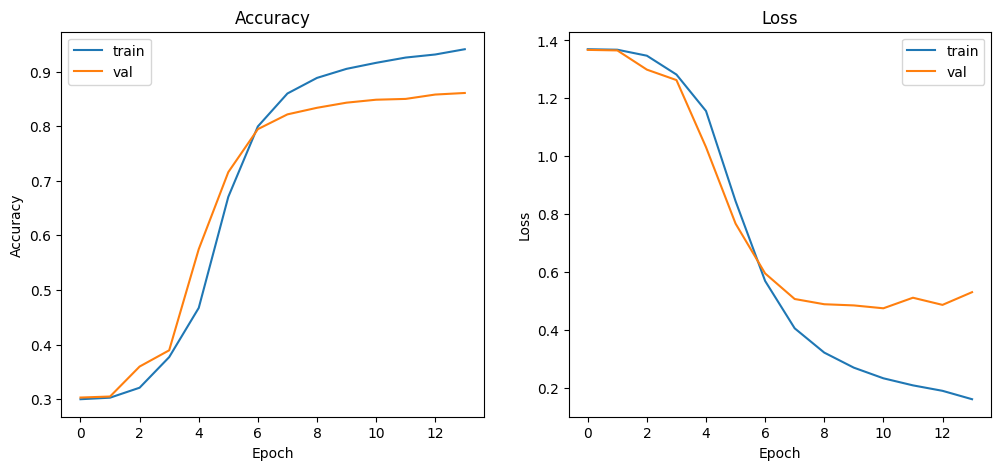

In [33]:
# =========================
# ACCURACY & LOSS PLOT
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Rezultati LSTM modela pokazuju postepen i stabilan proces učenja. U početnim epohama, accuracy raste sporije u odnosu na druge modele, što je očekivano jer LSTM mora da nauči sekvencijalne zavisnosti između reči. Kako trening napreduje, dolazi do značajnog poboljšanja performansi, što ukazuje da model uspešno hvata kontekst i odnose unutar teksta.

Kriva accuracy pokazuje kontinuiran rast na trening skupu, dok validaciona accuracy prati sličan trend, ali sa manjim oscilacijama. Loss funkcija opada kroz epohe, što znači da model sve bolje minimizuje grešku. U kasnijim epohama može se primetiti blago razdvajanje između trening i validacionog loss-a, što ukazuje na početak overfitting-a, ali je ovaj efekat efikasno ublažen korišćenjem Dropout slojeva, SpatialDropout-a, kao i callback funkcija poput EarlyStopping i ReduceLROnPlateau.

Matrica konfuzije pokazuje da model relativno dobro klasifikuje dominantne klase, dok se greške najčešće javljaju između semantički sličnih kategorija, poput „Neutral“ i „Positive“. Ovo je očekivano jer su granice između ovih klasa često nejasne čak i u ljudskoj interpretaciji. Ukupni rezultati ukazuju da LSTM model dobro koristi sekvencijalne informacije, ali nije najefikasniji za ovaj tip kratkih tekstova.

In [34]:
from keras.models import Model
from keras.layers import Input, Embedding, Dense, Dropout, SpatialDropout1D
from keras.layers import Conv1D, GlobalMaxPooling1D
from keras.layers import TextVectorization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

from keras import backend as K
K.clear_session()

In [35]:
# =========================
# CNN MODEL
# =========================
def build_cnn():
    inp = Input(shape=(MAX_LEN,), name='input')

    x = Embedding(MAX_VOCAB, EMBED_DIM, name='embed')(inp)
    x = SpatialDropout1D(0.2)(x)

    x = Conv1D(256, 3, activation='relu', padding='same')(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)

    x = GlobalMaxPooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inp, out, name='CNN_TextClassifier')
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    return model


cnn_model = build_cnn()
cnn_model.summary()


Model: "CNN_TextClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Embedding)               │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,020 (15.50 MB)

 Trainable params: 4,062,020 (15.50 MB)

 Non-trainable params: 0 (0.00 B)

CNN model, sa druge strane, fokusira se na lokalne obrasce u tekstu. Nakon embedding sloja, primenjuju se konvolucioni slojevi (Conv1D) koji funkcionišu kao detektori n-gram obrazaca (npr. bigrama i trigrama). Svaki filter „klizi“ kroz tekst i detektuje specifične obrasce koji mogu biti indikativni za sentiment. Nakon toga se koristi GlobalMaxPooling sloj koji izdvaja najvažniju aktivaciju svakog filtera, čime se dobija kompaktna reprezentacija celog teksta. Ova reprezentacija se zatim prosleđuje kroz Dense slojeve za konačnu klasifikaciju. CNN modeli su brži i efikasniji u hvatanju lokalnih obrazaca, ali nemaju eksplicitnu memoriju za dugoročne zavisnosti.

In [36]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

In [37]:
# =========================
# TRAIN CNN
# =========================
history_cnn = cnn_model.fit(
    X_train_seq_dl,
    y_train_cat_dl,
    validation_data=(X_val_seq_dl, y_val_cat_dl),
    epochs=15,
    batch_size=128,
    callbacks=CALLBACKS
)

Epoch 1/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5440 - loss: 1.0691 - val_accuracy: 0.7257 - val_loss: 0.7344 - learning_rate: 0.0010
Epoch 2/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.8072 - loss: 0.5333 - val_accuracy: 0.8118 - val_loss: 0.5181 - learning_rate: 0.0010
Epoch 3/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.8957 - loss: 0.2970 - val_accuracy: 0.8466 - val_loss: 0.4424 - learning_rate: 0.0010
Epoch 4/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9276 - loss: 0.2044 - val_accuracy: 0.8551 - val_loss: 0.4680 - learning_rate: 0.0010
Epoch 5/15
445/446 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9384 - loss: 0.1718
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
446/446 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.9414 - loss: 0.1622 - val_accuracy: 0.8530 - val_loss: 0.5318 - learning_rate: 0.0010
Epoch 6/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9571 - los

In [38]:
# =========================
# EVALUATION
# =========================
y_pred_cnn = np.argmax(cnn_model.predict(X_val_seq_dl), axis=1)

acc_cnn = accuracy_score(y_val_dl, y_pred_cnn)
print(f"\nValidation Accuracy: {acc_cnn:.4f}")

print(classification_report(
    y_val_dl,
    y_pred_cnn,
    target_names=le.classes_
))

446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Validation Accuracy: 0.8466
              precision    recall  f1-score   support

  Irrelevant       0.84      0.80      0.82      2495
    Negative       0.87      0.88      0.88      4321
     Neutral       0.83      0.84      0.84      3518
    Positive       0.83      0.85      0.84      3929

    accuracy                           0.85     14263
   macro avg       0.84      0.84      0.84     14263
weighted avg       0.85      0.85      0.85     14263



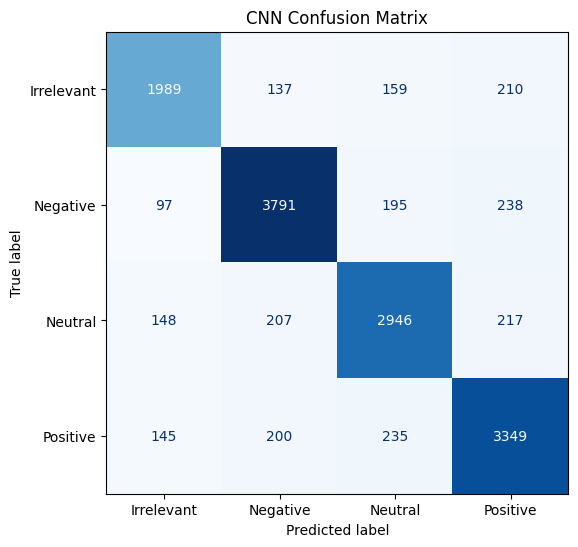

In [39]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val_dl, y_pred_cnn)

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(
    cm,
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap='Blues')

plt.title("CNN Confusion Matrix")
plt.show()


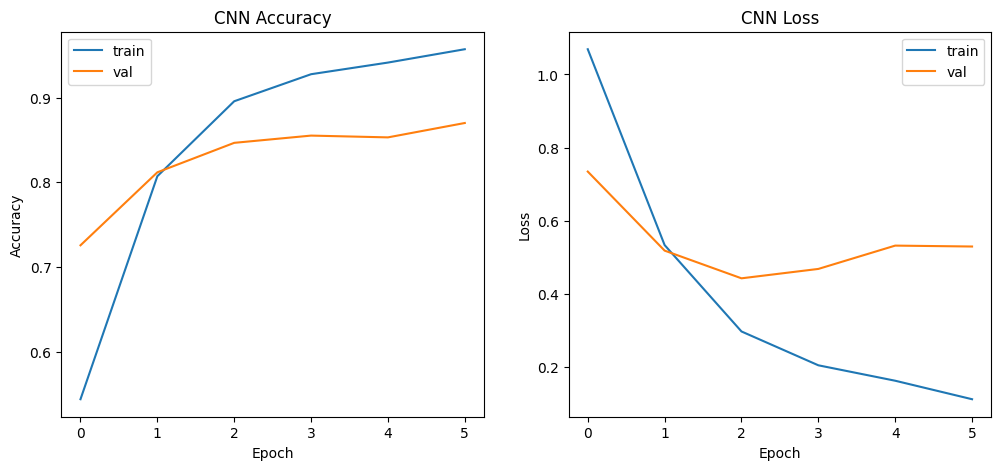

In [40]:
# =========================
# ACCURACY & LOSS PLOT
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='train')
plt.plot(history_cnn.history['val_accuracy'], label='val')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='train')
plt.plot(history_cnn.history['val_loss'], label='val')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

CNN model pokazuje znatno bržu konvergenciju u odnosu na LSTM. Već u ranim epohama dolazi do naglog rasta accuracy metrike, što ukazuje da model vrlo efikasno prepoznaje lokalne obrasce u tekstu, kao što su karakteristične kombinacije reči (npr. bigrami i trigrame).

Kriva accuracy brzo dostiže visoke vrednosti i zatim se stabilizuje, dok loss funkcija brzo opada i ostaje relativno stabilna. Validacioni rezultati prate trening performanse bez velikih odstupanja, što ukazuje na dobru generalizaciju modela. I ovde se može uočiti blago razdvajanje krivih u kasnijim epohama, ali je ono kontrolisano primenom Dropout slojeva, kao i adaptivnim smanjenjem learning rate-a putem ReduceLROnPlateau.

Matrica konfuzije kod CNN modela pokazuje vrlo dobre rezultate na svim klasama, sa visokim vrednostima na dijagonali. Greške su raspoređene slično kao kod LSTM-a, ali u manjoj meri, što potvrđuje da CNN model bolje hvata ključne obrasce u podacima. Ovaj model postiže najbolje ukupne rezultate, što sugeriše da su lokalni tekstualni obrasci dominantan faktor u rešavanju ovog problema.

In [41]:
from keras.models import Model
from keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from keras.layers import Conv1D, GlobalMaxPooling1D, Bidirectional
from keras.layers import TextVectorization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical
from keras.layers import Reshape

from keras import backend as K
K.clear_session()

In [42]:
# =========================
# CNN + LSTM MODEL
# =========================
from keras.layers import Bidirectional
from keras.regularizers import l2

def build_cnn_lstm():

    inp = Input(shape=(MAX_LEN,), name='input')

    x = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
    x = SpatialDropout1D(0.2)(x)

    # CNN feature extractor
    x = Conv1D(256, 3, activation='relu', padding='same')(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)

    # LSTM
    x = Bidirectional(LSTM(64, dropout=0.2))(x)

    # Dense deo
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model



cnn_lstm_model = build_cnn_lstm()
cnn_lstm_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,160,836 (15.87 MB)

 Trainable params: 4,160,836 (15.87 MB)

 Non-trainable params: 0 (0.00 B)

Kombinovani CNN-LSTM model pokušava da spoji prednosti oba pristupa. U ovoj arhitekturi, konvolucioni slojevi se koriste kao ekstraktori lokalnih karakteristika iz teksta, bez gubitka sekvencijalne strukture (zato se ne koristi pooling pre LSTM-a). Dobijena sekvenca se zatim prosleđuje LSTM sloju koji modeluje zavisnosti između tih lokalnih obrazaca kroz vreme. Na ovaj način model prvo uči „šta je važno“ na lokalnom nivou (CNN), a zatim „kako je to povezano“ kroz sekvencu (LSTM). Na kraju, Dense slojevi vrše klasifikaciju. Ova arhitektura je kompleksnija i potencijalno moćnija, ali zahteva pažljivo podešavanje hiperparametara kako bi se izbegli problemi sa učenjem ili overfittingom.

In [43]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

In [44]:
# =========================
# TRAIN MODEL
# =========================
history_cnn_lstm = cnn_lstm_model.fit(
    X_train_seq_dl,
    y_train_cat_dl,
    validation_data=(X_val_seq_dl, y_val_cat_dl),
    epochs=15,
    batch_size=128,
    callbacks=CALLBACKS
)

Epoch 1/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.5370 - loss: 1.0802 - val_accuracy: 0.6762 - val_loss: 0.8173 - learning_rate: 0.0010
Epoch 2/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 54s 122ms/step - accuracy: 0.7656 - loss: 0.6363 - val_accuracy: 0.7759 - val_loss: 0.6145 - learning_rate: 0.0010
Epoch 3/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 45s 100ms/step - accuracy: 0.8588 - loss: 0.3988 - val_accuracy: 0.8211 - val_loss: 0.5084 - learning_rate: 0.0010
Epoch 4/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.8977 - loss: 0.2894 - val_accuracy: 0.8373 - val_loss: 0.5008 - learning_rate: 0.0010
Epoch 5/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 41s 92ms/step - accuracy: 0.9205 - loss: 0.2267 - val_accuracy: 0.8453 - val_loss: 0.5222 - learning_rate: 0.0010
Epoch 6/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9313 - loss: 0.1951
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
446/446 ━━━━━━━━━━━━━━━━━━━━ 38s 86ms/step - accuracy: 0.9338 - l

In [45]:
# =========================
# EVALUATION
# =========================
y_pred_cnn_lstm = np.argmax(
    cnn_lstm_model.predict(X_val_seq_dl),
    axis=1
)

acc_cnn_lstm = accuracy_score(y_val_dl, y_pred_cnn_lstm)

print(f"\nValidation Accuracy: {acc_cnn_lstm:.4f}")

print(classification_report(
    y_val_dl,
    y_pred_cnn_lstm,
    target_names=le.classes_
))

446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

Validation Accuracy: 0.8373
              precision    recall  f1-score   support

  Irrelevant       0.79      0.80      0.80      2495
    Negative       0.85      0.89      0.87      4321
     Neutral       0.85      0.80      0.82      3518
    Positive       0.84      0.84      0.84      3929

    accuracy                           0.84     14263
   macro avg       0.83      0.83      0.83     14263
weighted avg       0.84      0.84      0.84     14263



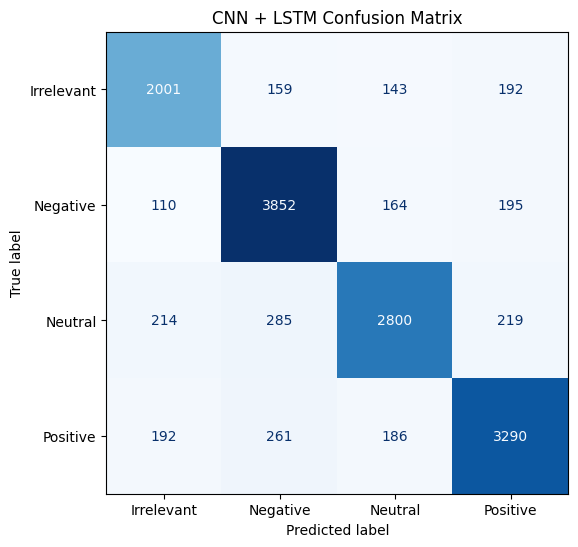

In [46]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val_dl, y_pred_cnn_lstm)

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay(
    cm,
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap='Blues')

plt.title("CNN + LSTM Confusion Matrix")
plt.show()

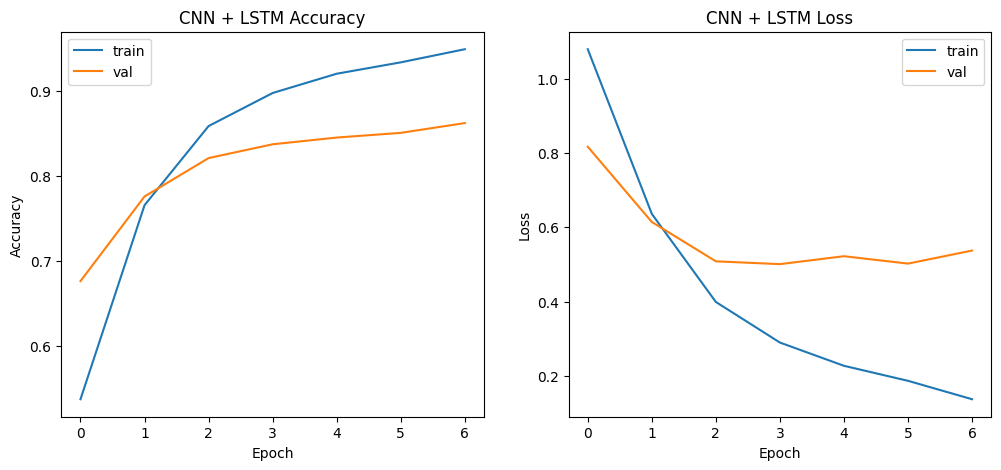

In [47]:
# =========================
# ACCURACY & LOSS PLOT
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn_lstm.history['accuracy'], label='train')
plt.plot(history_cnn_lstm.history['val_accuracy'], label='val')
plt.title('CNN + LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn_lstm.history['loss'], label='train')
plt.plot(history_cnn_lstm.history['val_loss'], label='val')
plt.title('CNN + LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Kombinovani CNN-LSTM model uvodi dodatnu kompleksnost sa ciljem da spoji prednosti oba pristupa. U početnim epohama, model uči sporije u odnosu na CNN, jer mora istovremeno da optimizuje i konvolucione i sekvencijalne slojeve. Međutim, nakon nekoliko epoha dolazi do stabilnog rasta accuracy metrike.

Kriva accuracy pokazuje dobar napredak, ali ne dostiže nivo CNN modela. Loss funkcija opada, ali sa nešto izraženijim oscilacijama, što je posledica složenije arhitekture. Validacioni rezultati prate trening performanse uz blaga odstupanja, a potencijalni overfitting je kontrolisan kombinacijom Dropout slojeva, regularizacije (L2) i callback funkcija.

Matrica konfuzije pokazuje uravnotežene performanse po klasama, ali bez značajnog poboljšanja u odnosu na CNN. Model uspeva da iskoristi i lokalne obrasce i sekvencijalni kontekst, ali u ovom slučaju dodatna kompleksnost ne donosi proporcionalno povećanje tačnosti.

# Zaključak poređenja modela

Na osnovu svih rezultata, može se zaključiti da CNN model postiže najbolje performanse i najstabilnije ponašanje tokom treninga. LSTM model pokazuje solidne rezultate i dobru sposobnost modelovanja konteksta, ali sporije uči. CNN-LSTM model, iako teorijski najmoćniji, ne donosi značajno poboljšanje u odnosu na CNN, što ukazuje da za ovaj dataset dominantnu ulogu imaju lokalni obrasci u tekstu.

Overfitting je prisutan u manjoj meri kod svih modela, ali je uspešno kontrolisan kroz kombinaciju Dropout slojeva, regularizacije, kao i callback mehanizama (EarlyStopping i ReduceLROnPlateau), čime je obezbeđena dobra generalizacija modela na validacionom skupu.

# 3. PREDOBRADA I TRENING MODELA GDE ZA TRENIRANJE KORISTIMO SKUP PODATAKA KOJI SADRŽI OKO 70 000 PODATKA, A ZA VALIDACIJU KORISTIMO DRUGI SKUP PODATAKA KOJI SADRŽI OKO 1000 PODATAKA

In [48]:
import os, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from keras.models import Model
from keras.layers import Input, Embedding, Dense, Dropout, SpatialDropout1D
from keras.layers import Conv1D, GlobalMaxPooling1D
from keras.layers import TextVectorization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

In [49]:
# =========================
# TEXT VECTORIZATION
# =========================
MAX_FEATURES = 30000
MAX_LEN = 60
EMBED_DIM = 128

vectorizer = TextVectorization(
    max_tokens=MAX_FEATURES,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

vectorizer.adapt(X_train)

Xtr_seq = vectorizer(np.array([[s] for s in X_train])).numpy()
Xvl_seq = vectorizer(np.array([[s] for s in X_val])).numpy()

ytr_cat = to_categorical(y_train, NUM_CLASSES)
yvl_cat = to_categorical(y_val, NUM_CLASSES)


Važna razlika u eksperimentalnoj postavci javlja se u načinu podele podataka. U prvom pristupu korišćen je jedan dataset sa približno 70.000 uzoraka, koji je podeljen na trening i validacioni skup (odnos 80/20). Ovakav pristup omogućava da model uči i validira se na podacima koji potiču iz iste distribucije, ali postoji potencijalni rizik od blagog optimizma u evaluaciji. U ovom pristupu korišćena su dva odvojena fajla – jedan za trening sa oko 70.000 uzoraka i drugi za validaciju sa 1.000 uzoraka. Ovaj pristup je metodološki strožiji jer validacioni skup predstavlja potpuno nezavisan skup podataka, što daje realističniju procenu performansi modela i njegove sposobnosti generalizacije.

In [50]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]


In [51]:
from keras.models import Model
from keras.layers import Input, Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

from keras import backend as K
K.clear_session()

In [ ]:
# =========================
# LSTM MODEL
# =========================
def build_lstm():

    inp = Input(shape=(MAX_LEN,), name='input')

    x = Embedding(MAX_FEATURES, EMBED_DIM, name='embed')(inp)
    x = SpatialDropout1D(0.2)(x)

    x = LSTM(128, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)(x)
    x = LSTM(64, dropout=0.2, recurrent_dropout=0.2)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inp, out, name='Stacked_LSTM')

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


lstm = build_lstm()
lstm.summary()


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Embedding)               │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,025,412 (15.36 MB)

 Trainable params: 4,025,412 (15.36 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# =========================
# TRAIN MODEL
# =========================
history = lstm.fit(
    Xtr_seq, ytr_cat,
    validation_data=(Xvl_seq, yvl_cat),
    epochs=15,
    batch_size=128,
    callbacks=CALLBACKS
)

Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 71s 122ms/step - accuracy: 0.3014 - loss: 1.3682 - val_accuracy: 0.2630 - val_loss: 1.3581 - learning_rate: 0.0010
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 62s 111ms/step - accuracy: 0.3716 - loss: 1.3361 - val_accuracy: 0.3470 - val_loss: 1.3436 - learning_rate: 0.0010
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 67s 121ms/step - accuracy: 0.3710 - loss: 1.3393 - val_accuracy: 0.3560 - val_loss: 1.3394 - learning_rate: 0.0010
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.3749 - loss: 1.3176 - val_accuracy: 0.3790 - val_loss: 1.2903 - learning_rate: 0.0010
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 56s 100ms/step - accuracy: 0.4596 - loss: 1.1573 - val_accuracy: 0.5420 - val_loss: 0.9886 - learning_rate: 0.0010
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 55s 99ms/step - accuracy: 0.5861 - loss: 0.9287 - val_accuracy: 0.7880 - val_loss: 0.6082 - learning_rate: 0.0010
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 60s 107ms/step - accuracy: 0.76

In [54]:
# =========================
# EVALUATION
# =========================
y_pred = np.argmax(lstm.predict(Xvl_seq), axis=1)

acc = accuracy_score(y_val, y_pred)

print(f"\nValidation Accuracy: {acc:.4f}")

print(classification_report(
    y_val,
    y_pred,
    target_names=le.classes_
))


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

Validation Accuracy: 0.9420
              precision    recall  f1-score   support

  Irrelevant       0.90      0.92      0.91       172
    Negative       0.96      0.97      0.96       266
     Neutral       0.95      0.92      0.94       285
    Positive       0.94      0.95      0.95       277

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



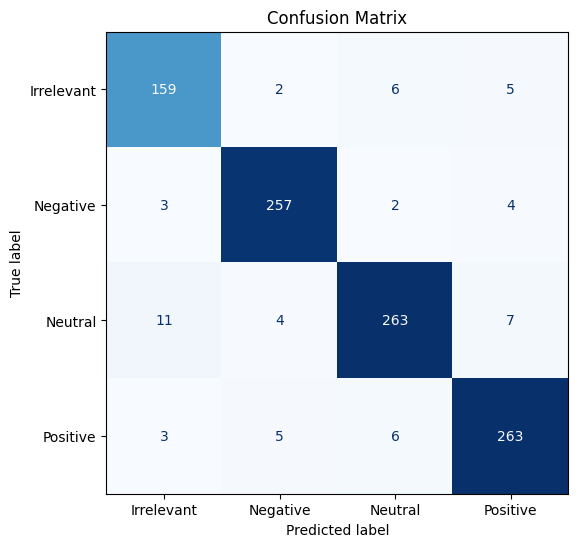

In [55]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay(
    cm,
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

LSTM model je pokazao veoma dobre rezultate kada je u pitanju klasifikacija tekstualnih podataka. Ako pogledamo konfuzionu matricu, odmah se primećuje da većina vrednosti leži na dijagonali, što znači da model u velikom broju slučajeva daje tačne predikcije. Ovo zapravo govori da model uspešno prepoznaje obrasce u podacima i da dobro razlikuje klase. Greške koje se javljaju uglavnom su između sličnih kategorija, što je u ovakvim zadacima sasvim očekivano.

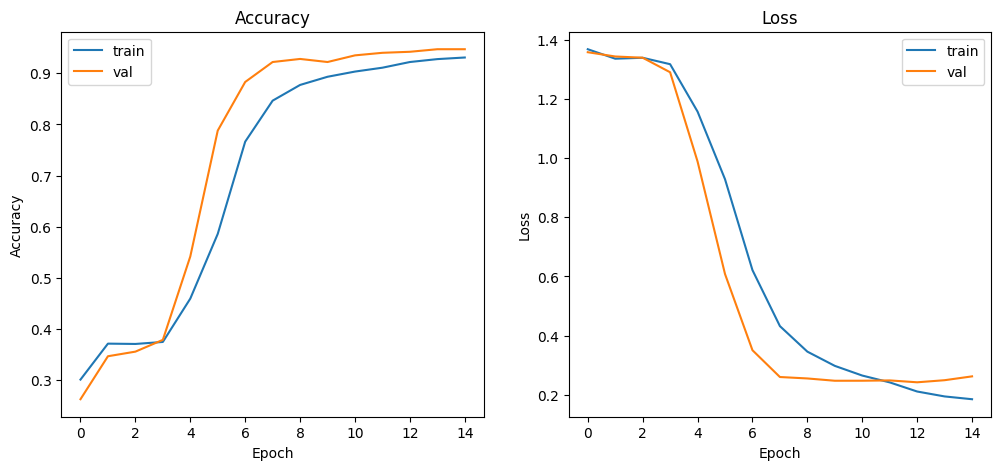

In [56]:
# =========================
# ACCURACY & LOSS PLOT
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Kada se posmatraju krive tačnosti tokom treniranja, vidi se da model postepeno napreduje iz epohe u epohu, bez nekih velikih oscilacija. Ono što je posebno dobro jeste to što su trening i validaciona tačnost veoma bliske. To znači da model ne „uči napamet“ podatke, već uspeva da nauči opšte obrasce koje može da primeni i na novim podacima.

Slično se može zaključiti i iz krive gubitka. Loss se smanjuje kako treniranje napreduje, a kasnije dolazi do stabilizacije, što je znak da model dostiže optimum. Takođe, korišćenje tehnika kao što su dropout i early stopping očigledno je pomoglo da se izbegne pretreniranost i da model ostane stabilan.

In [57]:
from keras import backend as K
K.clear_session()

In [58]:
# =========================
# CNN MODEL
# =========================
def build_cnn():

    inp = Input(shape=(MAX_LEN,), name="input")

    x = Embedding(MAX_FEATURES, EMBED_DIM, name="embed")(inp)
    x = SpatialDropout1D(0.2)(x)

    x = Conv1D(256, 3, activation="relu", padding="same")(x)
    x = Conv1D(128, 3, activation="relu", padding="same")(x)

    x = GlobalMaxPooling1D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inp, out, name="CNN")

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn = build_cnn()
cnn.summary()


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed (Embedding)               │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,020 (15.50 MB)

 Trainable params: 4,062,020 (15.50 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

In [60]:
# =========================
# TRAIN CNN
# =========================
history = cnn.fit(
    Xtr_seq, ytr_cat,
    validation_data=(Xvl_seq, yvl_cat),
    epochs=15,
    batch_size=128,
    callbacks=CALLBACKS
)


Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.5726 - loss: 1.0221 - val_accuracy: 0.8730 - val_loss: 0.4242 - learning_rate: 0.0010
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.8322 - loss: 0.4691 - val_accuracy: 0.9400 - val_loss: 0.1970 - learning_rate: 0.0010
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.9045 - loss: 0.2649 - val_accuracy: 0.9560 - val_loss: 0.1703 - learning_rate: 0.0010
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.9315 - loss: 0.1875 - val_accuracy: 0.9530 - val_loss: 0.1926 - learning_rate: 0.0010
Epoch 5/15
557/558 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9432 - loss: 0.1540
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
558/558 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.9440 - loss: 0.1506 - val_accuracy: 0.9610 - val_loss: 0.1887 - learning_rate: 0.0010
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.9583 - los

In [61]:
# =========================
# EVALUATION
# =========================
y_pred = np.argmax(cnn.predict(Xvl_seq), axis=1)

acc = accuracy_score(y_val, y_pred)

print(f"\nValidation Accuracy: {acc:.4f}")

print(classification_report(
    y_val,
    y_pred,
    target_names=le.classes_
))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Validation Accuracy: 0.9560
              precision    recall  f1-score   support

  Irrelevant       0.95      0.92      0.94       172
    Negative       0.98      0.97      0.97       266
     Neutral       0.96      0.95      0.95       285
    Positive       0.94      0.97      0.95       277

    accuracy                           0.96      1000
   macro avg       0.96      0.95      0.95      1000
weighted avg       0.96      0.96      0.96      1000



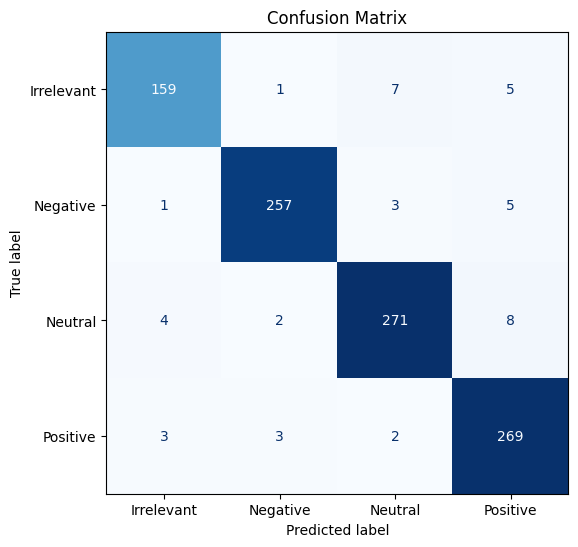

In [62]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay(
    cm,
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap="Blues")

plt.title("Confusion Matrix")
plt.show()


CNN model je takođe dao veoma dobre rezultate, što se jasno vidi iz konfuzione matrice. Većina primera je pravilno klasifikovana, a to znači da model uspešno prepoznaje ključne obrasce u tekstu. CNN je posebno dobar u hvatanju lokalnih karakteristika, kao što su određene fraze ili kombinacije reči koje su tipične za neku klasu.

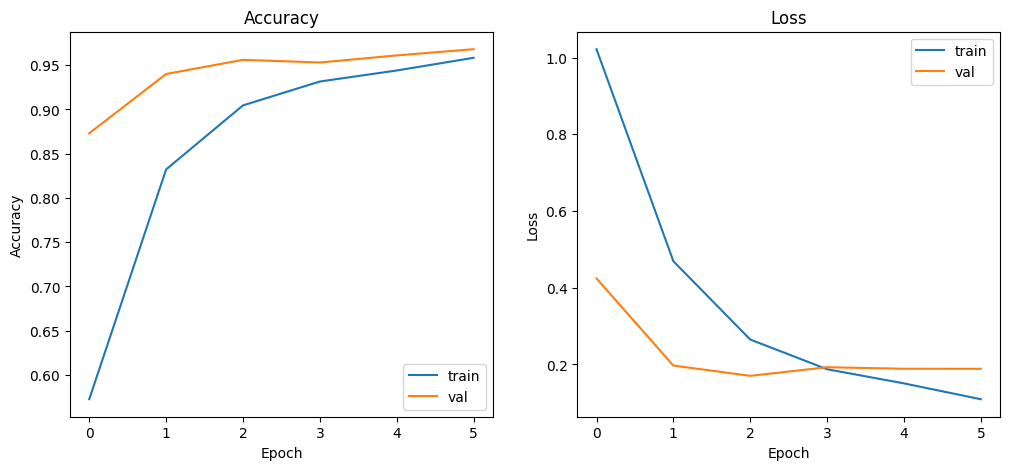

In [63]:
# =========================
# ACCURACY & LOSS
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

Jedna od najvećih prednosti ovog modela je brzina učenja. Već nakon nekoliko epoha model dostiže visoku tačnost, što se vidi iz grafika. To ga čini veoma praktičnim za primenu, posebno kada se radi sa većim skupovima podataka.

Kriva gubitka je stabilna i opada bez velikih skokova, što pokazuje da je proces treniranja bio dobro podešen. Takođe, razlika između trening i validacionih rezultata nije velika, pa možemo reći da model dobro generalizuje i da nema izražen problem overfitting-a.

In [64]:
np.unique(y_train, return_counts=True)
np.unique(y_val, return_counts=True)

(array([0, 1, 2, 3]), array([172, 266, 285, 277]))

In [65]:
from keras.models import Model
from keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D
from keras.layers import LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from keras.layers import Reshape
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from keras.layers import Bidirectional
from keras.regularizers import l2

from keras import backend as K
K.clear_session()

In [66]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

In [67]:
# =========================
# CNN + BiLSTM MODEL
# =========================
def build_cnn_lstm():

    inp = Input(shape=(MAX_LEN,), name='input')

    x = Embedding(MAX_VOCAB, EMBED_DIM)(inp)
    x = SpatialDropout1D(0.2)(x)

    # CNN feature extractor
    x = Conv1D(256, 3, activation='relu', padding='same')(x)
    x = Conv1D(128, 3, activation='relu', padding='same')(x)

    # LSTM
    x = Bidirectional(LSTM(64, dropout=0.2))(x)

    # Dense deo
    x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_lstm = build_cnn_lstm()
cnn_lstm.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 60, 128)        │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 60, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,160,836 (15.87 MB)

 Trainable params: 4,160,836 (15.87 MB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# =========================
# CALLBACKS
# =========================
CALLBACKS = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

In [69]:
# =========================
# TRAIN MODEL
# =========================
history = cnn_lstm.fit(
    Xtr_seq,
    ytr_cat,
    validation_data=(Xvl_seq, yvl_cat),
    epochs=15,
    batch_size=128,
    callbacks=CALLBACKS
)


Epoch 1/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 47s 79ms/step - accuracy: 0.5889 - loss: 0.9946 - val_accuracy: 0.8740 - val_loss: 0.3994 - learning_rate: 0.0010
Epoch 2/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - accuracy: 0.8296 - loss: 0.4866 - val_accuracy: 0.9320 - val_loss: 0.2290 - learning_rate: 0.0010
Epoch 3/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.8902 - loss: 0.3129 - val_accuracy: 0.9440 - val_loss: 0.2045 - learning_rate: 0.0010
Epoch 4/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 43s 77ms/step - accuracy: 0.9146 - loss: 0.2403 - val_accuracy: 0.9510 - val_loss: 0.1982 - learning_rate: 0.0010
Epoch 5/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.9311 - loss: 0.1920 - val_accuracy: 0.9640 - val_loss: 0.1743 - learning_rate: 0.0010
Epoch 6/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 42s 75ms/step - accuracy: 0.9402 - loss: 0.1638 - val_accuracy: 0.9630 - val_loss: 0.1806 - learning_rate: 0.0010
Epoch 7/15
558/558 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.9481 - lo

In [70]:
# =========================
# EVALUATION
# =========================
y_pred = np.argmax(cnn_lstm.predict(Xvl_seq), axis=1)

acc = accuracy_score(y_val, y_pred)

print(f"\nValidation Accuracy: {acc:.4f}")

print(classification_report(
    y_val,
    y_pred,
    target_names=le.classes_
))


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Validation Accuracy: 0.9640
              precision    recall  f1-score   support

  Irrelevant       0.96      0.94      0.95       172
    Negative       0.96      0.98      0.97       266
     Neutral       0.96      0.96      0.96       285
    Positive       0.97      0.96      0.97       277

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



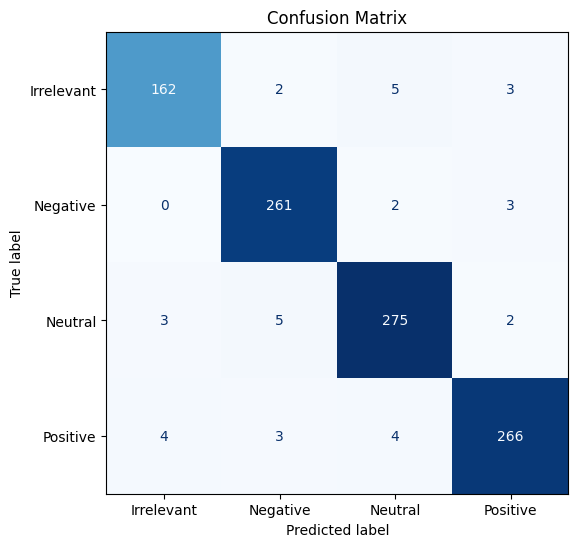

In [71]:
# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_val, y_pred)

fig, ax = plt.subplots(figsize=(7,6))

ConfusionMatrixDisplay(
    cm,
    display_labels=le.classes_
).plot(ax=ax, colorbar=False, cmap='Blues')

plt.title("Confusion Matrix")
plt.show()


Kombinovani CNN + BiLSTM model se pokazao kao najjači među testiranim pristupima. U konfuzionoj matrici se vidi još izraženija dijagonala, odnosno još veći broj tačnih klasifikacija u odnosu na prethodne modele. To znači da model pravi najmanje grešaka i da najbolje razdvaja klase.

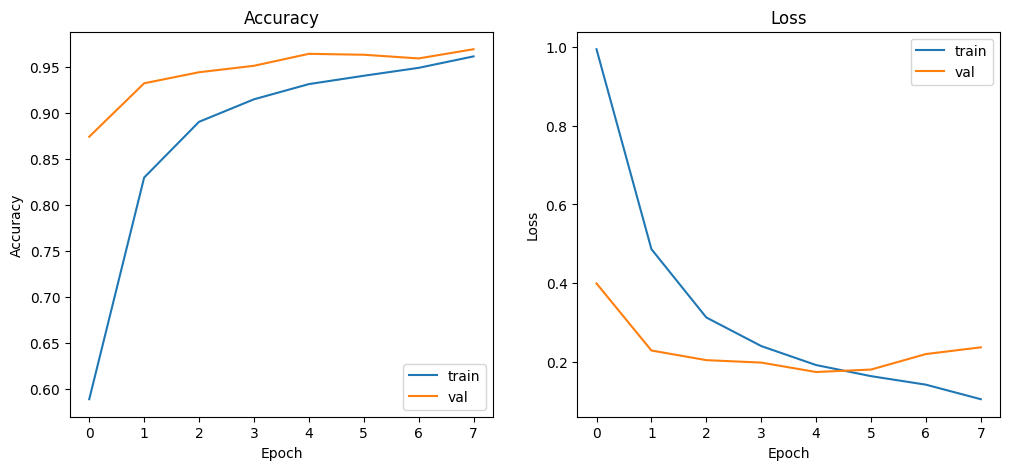

In [72]:
# =========================
# ACCURACY & LOSS
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Ovaj model koristi prednosti oba pristupa – CNN prepoznaje lokalne obrasce u tekstu, dok BiLSTM analizira sekvencu u oba smera i hvata širi kontekst. Upravo ta kombinacija daje najbolje rezultate, jer model istovremeno razume i detalje i celinu.

Kada se pogledaju krive tačnosti, vidi se stabilan rast i veoma dobre krajnje vrednosti. Takođe, trening i validaciona tačnost su skoro iste, što znači da model odlično generalizuje. Uprkos tome što je složeniji, ne dolazi do značajnog overfitting-a, što je veliki plus.

Kriva gubitka dodatno potvrđuje kvalitet modela – loss opada brzo i stabilno, i dostiže niže vrednosti nego kod ostalih modela. To ukazuje da model ne samo da daje tačne predikcije, već to radi sa većom sigurnošću.

# ZAKLJUČAK

U sekciji 2 primenjen je pristup podele jednog skupa podataka na trening i validacioni, čime je efektivna količina podataka dostupna za učenje modela bila smanjena. Kao posledica toga, svi modeli su ostvarili nešto niže vrednosti tačnosti, kao i blago slabiju stabilnost tokom treniranja. Ipak, u takvim uslovima se CNN model izdvojio kao najpouzdaniji, pokazujući najbolji balans između preciznosti i stabilnosti, uz konzistentno ponašanje tokom epoha.

U skladu sa smernicama navedenim na zvaničnoj stranici skupa podataka, gde je preporučeno korišćenje unapred definisanih i odvojenih fajlova za treniranje i validaciju, u sekciji 3 primenjen je takav pristup eksperimentalnoj postavci. Konkretno, za treniranje modela korišćen je originalni trening skup koji sadrži približno 70.000 uzoraka, dok je za validaciju korišćen zaseban skup od 1.000 uzoraka.

Rezultati dobijeni u ovom eksperimentalnom okruženju ukazuju na značajno unapređenje performansi svih posmatranih modela. Uočava se porast tačnosti, kao i stabilnije krive učenja, što upućuje na bolju sposobnost generalizacije i efikasnije usvajanje obrazaca iz podataka. Ovakvo ponašanje modela može se direktno dovesti u vezu sa većom količinom dostupnih podataka za treniranje, što omogućava kvalitetnije učenje reprezentacija.

U okviru ovog scenarija, hibridni CNN + BiLSTM model ostvario je najbolje rezultate, sa postignutom tačnošću od 96,4%, čime je potvrđena prednost kombinovanja konvolucionih slojeva za ekstrakciju lokalnih karakteristika i dvosmernih LSTM slojeva za modelovanje sekvencijalnog konteksta. Pored toga, CNN model je zadržao veoma konkurentne performanse, ostvarivši tačnost od približno 95,6%, uz znatno jednostavniju arhitekturu i manju računsku složenost, što ga čini efikasnim i praktičnim rešenjem u situacijama sa ograničenim resursima.